In [471]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

Download libraries

**1. Data Retrieval**

In [472]:
!mkdir data

mkdir: cannot create directory ‘data’: File exists


Create a data folder

In [473]:
df_train = pd.read_csv('data/train.csv')
df_test = pd.read_csv('data/test.csv')

In [474]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

We note here that memory usage: 924.0+ KB

In [475]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1459 entries, 0 to 1458
Data columns (total 80 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1459 non-null   int64  
 1   MSSubClass     1459 non-null   int64  
 2   MSZoning       1455 non-null   object 
 3   LotFrontage    1232 non-null   float64
 4   LotArea        1459 non-null   int64  
 5   Street         1459 non-null   object 
 6   Alley          107 non-null    object 
 7   LotShape       1459 non-null   object 
 8   LandContour    1459 non-null   object 
 9   Utilities      1457 non-null   object 
 10  LotConfig      1459 non-null   object 
 11  LandSlope      1459 non-null   object 
 12  Neighborhood   1459 non-null   object 
 13  Condition1     1459 non-null   object 
 14  Condition2     1459 non-null   object 
 15  BldgType       1459 non-null   object 
 16  HouseStyle     1459 non-null   object 
 17  OverallQual    1459 non-null   int64  
 18  OverallC

In [476]:
df_train.shape

(1460, 81)

In [477]:
df_test.shape

(1459, 80)

In [478]:
df_train.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


The files were loaded into the data folder, read, and their dimensions were determined.

In [479]:
df_train[df_train.select_dtypes(['object']).columns] = df_train.select_dtypes(['object']).apply(lambda x: x.astype('category'))

In [480]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype   
---  ------         --------------  -----   
 0   Id             1460 non-null   int64   
 1   MSSubClass     1460 non-null   int64   
 2   MSZoning       1460 non-null   category
 3   LotFrontage    1201 non-null   float64 
 4   LotArea        1460 non-null   int64   
 5   Street         1460 non-null   category
 6   Alley          91 non-null     category
 7   LotShape       1460 non-null   category
 8   LandContour    1460 non-null   category
 9   Utilities      1460 non-null   category
 10  LotConfig      1460 non-null   category
 11  LandSlope      1460 non-null   category
 12  Neighborhood   1460 non-null   category
 13  Condition1     1460 non-null   category
 14  Condition2     1460 non-null   category
 15  BldgType       1460 non-null   category
 16  HouseStyle     1460 non-null   category
 17  OverallQual    1460 non-null   in

Convert all text columns (objects) into categories  note : After the conversion we made, it became memory usage: 505.4 KB

In [481]:
df_train[df_train.select_dtypes(['float64']).columns] = df_train.select_dtypes(['float64']).apply(lambda x: x.astype('float32'))
df_train[df_train.select_dtypes(['int64']).columns] = df_train.select_dtypes(['int64']).apply(lambda x: x.astype('int32'))

In [482]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype   
---  ------         --------------  -----   
 0   Id             1460 non-null   int32   
 1   MSSubClass     1460 non-null   int32   
 2   MSZoning       1460 non-null   category
 3   LotFrontage    1201 non-null   float32 
 4   LotArea        1460 non-null   int32   
 5   Street         1460 non-null   category
 6   Alley          91 non-null     category
 7   LotShape       1460 non-null   category
 8   LandContour    1460 non-null   category
 9   Utilities      1460 non-null   category
 10  LotConfig      1460 non-null   category
 11  LandSlope      1460 non-null   category
 12  Neighborhood   1460 non-null   category
 13  Condition1     1460 non-null   category
 14  Condition2     1460 non-null   category
 15  BldgType       1460 non-null   category
 16  HouseStyle     1460 non-null   category
 17  OverallQual    1460 non-null   in

Convert decimal numbers float64 to float32 and integers int64 to int32 note : After the conversion we made, it became memory usage: 288.7 KB

**2. Data Cleaning**

In [483]:
missing_values = df_train.isnull().sum().sort_values(ascending=False).head()
missing_values

,0
PoolQC,1453
MiscFeature,1406
Alley,1369
Fence,1179
MasVnrType,872


Check Missing Values

In [484]:
print(df_train.isnull().sum().sum())

7829


In [485]:
df_train[['PoolQC', 'MiscFeature', 'Alley', 'Fence']].isnull().sum()

,0
PoolQC,1453
MiscFeature,1406
Alley,1369
Fence,1179


In [486]:
missing_columns = ['PoolQC', 'MiscFeature', 'Alley', 'Fence']

for df in [df_train, df_test]:
    for col in missing_columns:
        if df[col].dtype.name == 'category':
            df[col] = df[col].cat.add_categories(['None'])

        df[col] = df[col].fillna('None')

In [487]:
df_train[['PoolQC', 'MiscFeature', 'Alley', 'Fence']].isnull().sum()

,0
PoolQC,0
MiscFeature,0
Alley,0
Fence,0


In [488]:
print(df_train.isnull().sum().sum())

2422


We solved the problem of missing values ​​in the category columns by replacing the NaN value with the None value because NaN in some columns does not mean the data is missing incorrectly, but rather it means the feature is not present in the house (e.g., there is no swimming pool).

In [489]:
special_columns = ['PoolQC', 'MiscFeature', 'Alley', 'Fence']
for col in special_columns:
  df_train[col] = df_train[col].fillna('None')
  df_test[col] = df_test[col].fillna('None')

We solved the missing values ​​issue in the numeric columns by taking the middle value from among the column values ​​and deleting the SalePrice column because it was not present in the data text.

In [490]:
categorical_cols = df_train.select_dtypes(include=['object']).columns
for col in categorical_cols:
 df_train[col] = df_train[col].fillna(df_train[col].mode()[0])
 df_test[col] = df_test[col].fillna(df_test[col].mode()[0])

We solved the problem of missing values ​​in text columns by taking the most frequently occurring value in the column.

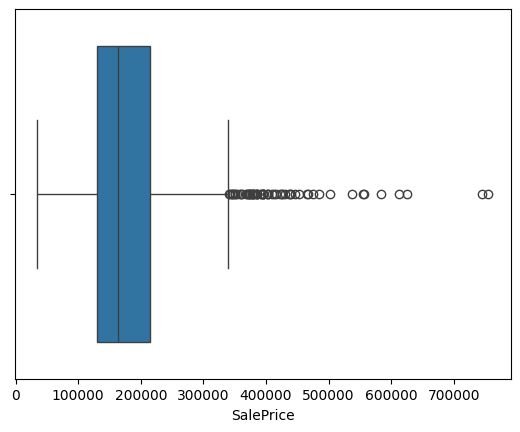

In [491]:
plt.figure()
sns.boxplot(x=df_train['SalePrice'])
plt.show()

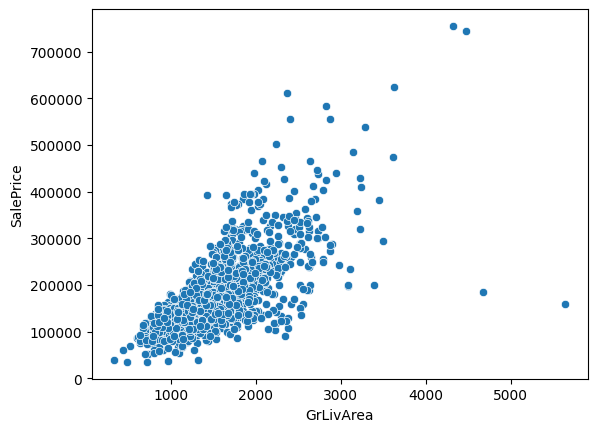

In [492]:
plt.figure()
sns.scatterplot(x=df_train['GrLivArea'], y=df_train['SalePrice'])
plt.show()

The goal is to draw a scatter plot to determine the relationship between a house's price and its size in order to highlight the anomaly.

In [493]:
df_train = df_train.drop(df_train[(df_train['GrLivArea'] > 4000) &
(df_train['SalePrice'] < 300000)].index)

Through this step, I removed the outliers from the training data where the houses (GrLivArea > 4000) have a low price (SalePrice < 300000).

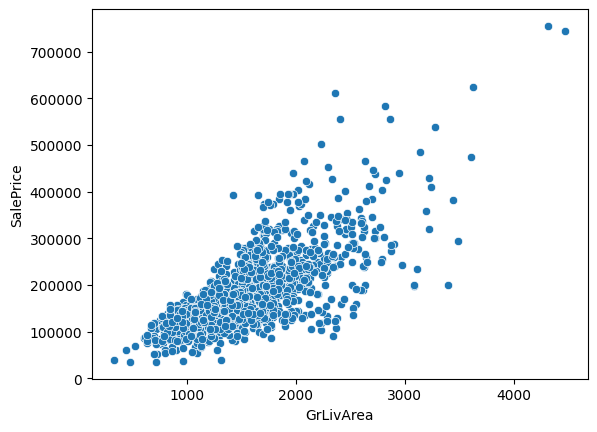

In [494]:
plt.figure()
sns.scatterplot(x=df_train['GrLivArea'], y=df_train['SalePrice'])
plt.show()

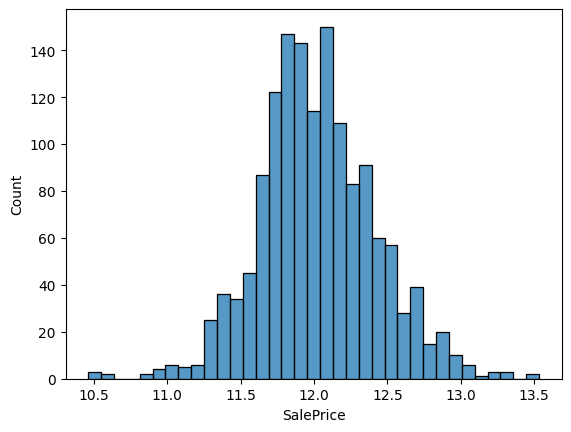

In [495]:
df_train['SalePrice'] = np.log1p(df_train['SalePrice'])
plt.figure()
sns.histplot(df_train['SalePrice'] )
plt.show()

Based on the available data, the SalePrice distribution is skewed to the right due to very high prices compared to other houses. Therefore, I used np.log1p, which reduces this skewness and makes the distribution closer to normal to improve model performance.

**3. Exploratory Data Analysis (EDA)**


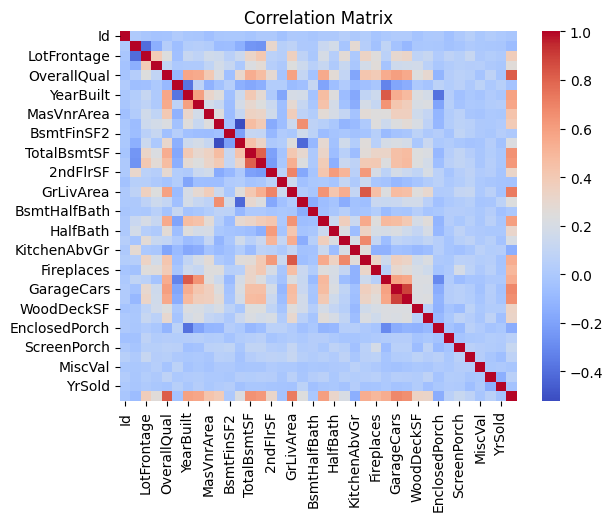

In [496]:
corr_matrix = df_train.corr(numeric_only=True)
plt.figure()
sns.heatmap(corr_matrix, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()


In [497]:
saleprice_corr = corr_matrix['SalePrice'].sort_values(ascending=False)
print(saleprice_corr.head(6))


SalePrice      1.000000
OverallQual    0.821405
GrLivArea      0.725211
GarageCars     0.681033
GarageArea     0.656129
TotalBsmtSF    0.647563
Name: SalePrice, dtype: float64


The correlation coefficient between the numerical columns was calculated, where values ​​close to 1 indicate a strong relationship and values ​​close to -1 indicate a weak relationship, and then it was plotted as a heat map to determine the strength of the relationship between the numerical variables in the data.

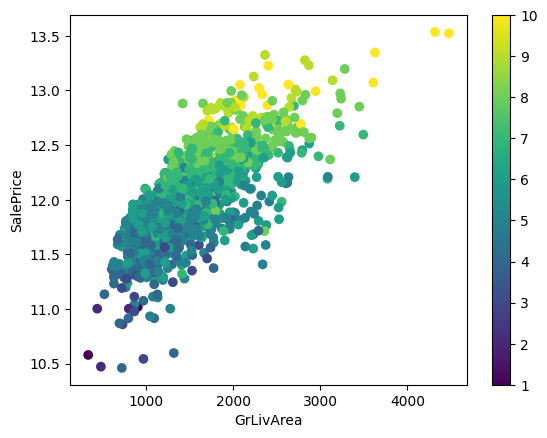

In [498]:
plt.figure()
scatter = plt.scatter(
df_train['GrLivArea'],
df_train['SalePrice'],
c=df_train['OverallQual'],
cmap='viridis'
)
plt.xlabel('GrLivArea')
plt.ylabel('SalePrice')
plt.colorbar(scatter)
plt.show()

This code draws a scatter diagram showing the relationship between the home's area (GrLivArea) and the sale price (SalePrice). Each point's color represents the home's quality value, with the color bar showing the difference in quality levels between homes.

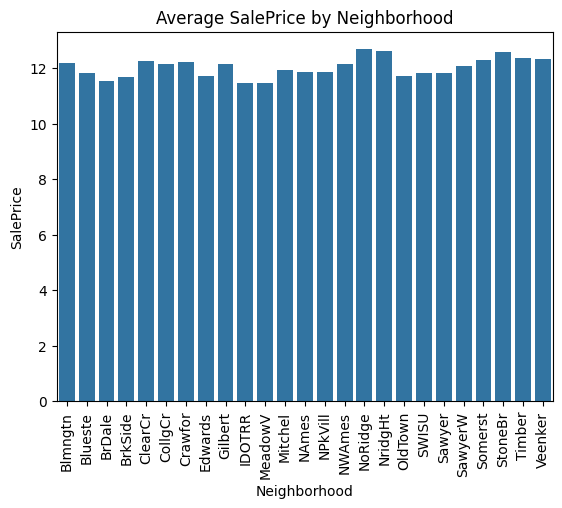

In [499]:
neighborhood_prices = df_train.groupby('Neighborhood')['SalePrice'].mean().reset_index()
plt.figure()
sns.barplot(
data=neighborhood_prices,
x='Neighborhood',
y='SalePrice'
)
plt.xticks(rotation=90)
plt.title('Average SalePrice by Neighborhood')
plt.show()


First, we calculate the average sale price for each neighborhood using GroupBy.

Then, a barplot is drawn where the X-axis represents the neighborhoods and the Y-axis represents the average price.

**4. Feature Engineering**

In [500]:
df_train['TotalSF'] = (
df_train['TotalBsmtSF'] +
df_train['1stFlrSF'] +
df_train['2ndFlrSF']
)
df_test['TotalSF'] = (
df_test['TotalBsmtSF'] +
df_test['1stFlrSF'] +
df_test['2ndFlrSF']
)

We are creating a new feature that represents the total area in square feet.

In [502]:
ordinal_cols = ['ExterQual', 'KitchenQual']
label_encoder = LabelEncoder()
for col in ordinal_cols:
   df_train[col] = label_encoder.fit_transform(df_train[col])



This code converts text values ​​in the ExterQual and KitchenQual columns to numbers using a LabelEncoder, making them usable in machine learning models.

The converter is trained on df_train data, and then the same conversion is applied to df_test to ensure encoding consistency between the data sets.

In [503]:
df_train = pd.get_dummies(df_train, columns=['Neighborhood', 'BldgType'])
df_test = pd.get_dummies(df_test, columns=['Neighborhood', 'BldgType'])


In [504]:
numeric_features = df_train.select_dtypes(include=['int64', 'float64']).columns
categorical_features = df_train.select_dtypes(include=['object']).columns
numeric_transformer = Pipeline(steps=[
('imputer', SimpleImputer(strategy='median')),
('scaler', StandardScaler())
])
categorical_transformer = Pipeline(steps=[
('imputer', SimpleImputer(strategy='most_frequent')),
('onehot', OneHotEncoder(handle_unknown='ignore'))
])
preprocessor = ColumnTransformer(
transformers=[
('num', numeric_transformer, numeric_features),
('cat', categorical_transformer, categorical_features)
]
)


This code prepares the data before training the Machine Learning model by separating it into numeric and categorical data, and then applies appropriate processing to each type using ColumnTransformer to combine all the transformations together in an orderly manner.